# Github Analyzer Notebook
Analyze all repositories under a GitHub account and produce a structured dataset.

## Step 1.1 — Setup & API Connection Test

In [9]:
import os
import time
from datetime import datetime

import pandas as pd
from dotenv import load_dotenv
from github import Auth, Github

load_dotenv(os.path.join(os.path.dirname(os.getcwd()), ".env"))

gh_token = os.getenv("GH_TOKEN")
if not gh_token:
    raise ValueError("GH_TOKEN not found in .env file")

g = Github(auth=Auth.Token(gh_token))
user = g.get_user()

rate = g.get_rate_limit().rate
print(f"Authenticated as: {user.login}")
print(f"Name: {user.name}")
print(f"Public repos: {user.public_repos}")
print(f"Private repos: {user.owned_private_repos}")
print(f"Rate limit remaining: {rate.remaining} / {rate.limit}")

Authenticated as: Alexxbyou
Name: AY
Public repos: 9
Private repos: None
Rate limit remaining: 4604 / 5000


## Step 1.2 — Retrieve Raw Repository List
Fetch all non-fork repos with metadata and language stats.

In [ ]:
def format_tech_stack(languages: dict, top_n: int = 3) -> str:
    """Format language bytes dict into 'Python (70%), JS (10%)' string."""
    total = sum(languages.values())
    if total == 0:
        return ""
    sorted_langs = sorted(languages.items(), key=lambda x: x[1], reverse=True)[:top_n]
    parts = [f"{lang} ({bytes_count / total * 100:.0f}%)" for lang, bytes_count in sorted_langs]
    return ", ".join(parts)


# Fetch all repos, exclude forks
all_repos = list(user.get_repos(affiliation="owner"))
repos = [r for r in all_repos if not r.fork]

print(f"Total repos (owner): {len(all_repos)}")
print(f"Non-fork repos: {len(repos)}")
print(f"Excluded forks: {len(all_repos) - len(repos)}")
print()
for r in repos:
    print(f"  {'[private]' if r.private else '[public] '} {r.name}")

## Step 1.3 — Retrieve Contribution Data Per Repo
For each repo: languages, branch count, contributor stats (commits/additions/deletions), activity dates.

In [ ]:
import json
from github import GithubException
from tqdm.auto import tqdm

username = user.login
results = []

# --- Cache setup ---
cache_dir = os.path.join(os.path.dirname(os.getcwd()), "Output", "cache")
os.makedirs(cache_dir, exist_ok=True)

def load_cache(repo_name):
    path = os.path.join(cache_dir, f"{repo_name}.json")
    if os.path.exists(path):
        with open(path, "r") as f:
            return json.load(f)
    return None

def save_cache(repo_name, data):
    path = os.path.join(cache_dir, f"{repo_name}.json")
    with open(path, "w") as f:
        json.dump(data, f, indent=2)

for i, repo in enumerate(repos):
    print(f"\n[{i+1}/{len(repos)}] {repo.name}", end="")

    cached = load_cache(repo.name)
    if cached:
        print("  (cached)")
        results.append(cached)
        continue

    print()

    row = {
        "repo_name": repo.name,
        "repo_description": repo.description or "",
        "visibility": "private" if repo.private else "public",
        "repo_size_kb": repo.size,
    }

    # --- Languages (top 3) ---
    languages = repo.get_languages()
    row["tech_stack"] = format_tech_stack(languages)
    print(f"  Languages: {row['tech_stack'] or '(none)'}")

    # --- Branch count ---
    row["no_branches"] = len(list(repo.get_branches()))
    print(f"  Branches: {row['no_branches']}")

    # --- Contributor stats (commits, additions, deletions) ---
    # Sum ALL contributors since these are solo-developed repos.
    # This avoids mismatches when local git username differs from GitHub login.
    row["commits_by_owner"] = 0
    row["lines_added"] = 0
    row["lines_deleted"] = 0

    stats = None
    for attempt in range(3):
        stats = repo.get_stats_contributors()
        if stats is not None:
            break
        print(f"  Stats not ready, retrying ({attempt+1}/3)...")
        time.sleep(2)

    if stats:
        for contributor in stats:
            row["commits_by_owner"] += contributor.total
            row["lines_added"] += sum(w.a for w in contributor.weeks)
            row["lines_deleted"] += sum(w.d for w in contributor.weeks)
    print(f"  Commits: {row['commits_by_owner']}  +{row['lines_added']} -{row['lines_deleted']}")

    # --- Activity dates (first & last commit, no author filter) ---
    row["activity_start_date"] = None
    row["activity_end_date"] = None

    try:
        commits = repo.get_commits()
        total_commits = commits.totalCount
        if total_commits > 0:
            latest_commit = commits[0]
            row["activity_end_date"] = latest_commit.commit.author.date.strftime("%Y-%m-%d")
            oldest_commit = commits[total_commits - 1]
            row["activity_start_date"] = oldest_commit.commit.author.date.strftime("%Y-%m-%d")
    except GithubException as e:
        print(f"  Skipping commits (repo may be empty): {e.data.get('message', e)}")

    print(f"  Activity: {row['activity_start_date']} → {row['activity_end_date']}")

    save_cache(repo.name, row)
    results.append(row)
    time.sleep(0.5)  # gentle rate-limit buffer

print(f"\n{'='*50}")
print(f"Done! Collected data for {len(results)} repos.")
print(f"Rate limit remaining: {g.get_rate_limit().rate.remaining}")
print(f"Cache dir: {cache_dir}")
print("Tip: delete cache dir to force a fresh fetch.")

## Step 1.4 — Build DataFrame & Export CSV

In [ ]:
ANONYMIZE = True

df = pd.DataFrame(results)
# exclude because these are forked and continued development of other projects, which skews the analysis of original solo projects
excl_projects = ["svc-inference", "DiffSinger-Solfege", "DiffSinger-Solfege-Inference-Code", "sparkify-music-streaming-data-analysis"]  # Example excluded projects

# Derive: net_lines_of_code
df["net_lines_of_code"] = df["lines_added"] - df["lines_deleted"]

# Derive: activity_span_days
df["activity_start_date"] = pd.to_datetime(df["activity_start_date"])
df["activity_end_date"] = pd.to_datetime(df["activity_end_date"])
df["activity_span_days"] = (df["activity_end_date"] - df["activity_start_date"]).dt.days
df["excl_line_counts"] = df["repo_name"].isin(excl_projects)

# Anonymize repo names and descriptions
if ANONYMIZE:
    df["repo_name"] = [f"project-{i+1:03d}" for i in range(len(df))]
    df["repo_description"] = ""

# Reorder columns to match requirements
column_order = [
    "repo_name",
    "repo_description",
    "visibility",
    "tech_stack",
    "repo_size_kb",
    "activity_start_date",
    "activity_end_date",
    "activity_span_days",
    "commits_by_owner",
    "lines_added",
    "lines_deleted",
    "net_lines_of_code",
    "no_branches",
    "excl_line_counts",
]
df = df[column_order]

# Sort by commits descending
df = df.sort_values("commits_by_owner", ascending=False).reset_index(drop=True)
df = df[(df["commits_by_owner"] > 0) & (df["repo_size_kb"] > 0)]  # Optional: filter out repos with zero commits and zero net lines of code


if ANONYMIZE:
    print("Anonymized: repo names replaced with project-001, project-002, ...")
    df.drop(columns=["repo_description"], inplace=True)

df

Anonymized: repo names replaced with project-001, project-002, ...


,repo_name,visibility,tech_stack,repo_size_kb,activity_start_date,activity_end_date,activity_span_days,commits_by_owner,lines_added,lines_deleted,net_lines_of_code,no_branches,excl_line_counts
0,project-034,private,"Python (52%), TypeScript (36%), Shell (8%)",37529,2025-09-11,2025-11-11,61.0,244,457900,318507,139393,7,False
1,project-037,private,"Python (98%), Shell (1%), Dockerfile (0%)",18433,2022-09-08,2026-01-28,1238.0,200,127246,118537,8709,1,True
2,project-023,private,"Swift (100%), Shell (0%)",11014,2025-12-19,2026-01-25,37.0,180,60509,33468,27041,1,False
3,project-006,private,"Swift (100%), Ruby (0%)",5207,2024-10-03,2025-07-07,277.0,63,118075,64440,53635,2,False
4,project-035,private,"Jupyter Notebook (72%), Python (16%), JavaScri...",254,2025-09-11,2025-09-23,12.0,62,14597,11523,3074,2,False
5,project-010,private,"Python (100%), Dockerfile (0%)",64921,2021-12-19,2026-01-28,1501.0,50,45638,2232,43406,1,True
6,project-024,private,"JavaScript (57%), TypeScript (31%), CSS (12%)",713,2026-01-08,2026-01-11,3.0,26,23097,766,22331,2,False
7,project-002,public,HTML (100%),253,2025-01-24,2025-06-19,146.0,21,275,194,81,1,False
8,project-001,private,"Python (48%), Jupyter Notebook (46%), TypeScri...",2644,2026-02-06,2026-02-09,3.0,20,12472,1709,10763,2,False
9,project-013,private,R (100%),602,2024-08-28,2025-06-20,296.0,18,6611,2674,3937,1,False


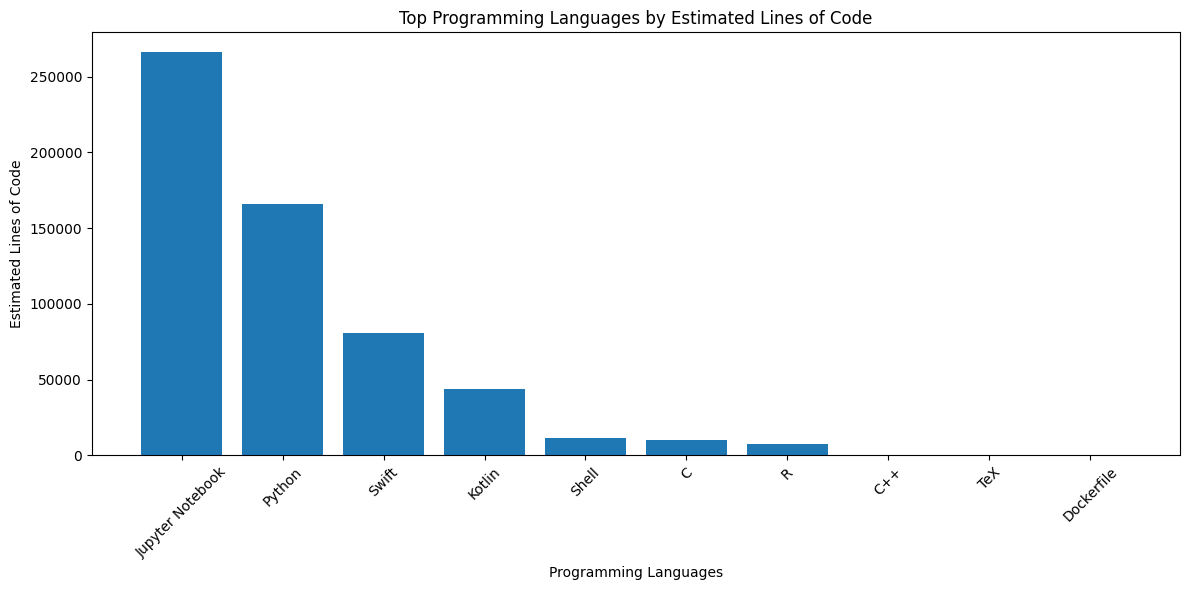

Total estimated lines of code in top languages: 267680


In [45]:
# estimated total top tech stacks:
# use the percentage breakdown in the "tech_stack" column and the total number of net lines of code to estimate the distribution of programming languages across all repos.
# show a bar chart of the top languages by estimated lines of code.
dict = {} # language -> total estimated lines of code across all repos
EXCL_FRONTEND_LANGS = {"JavaScript", "TypeScript", "HTML", "CSS", "Vue", "React", "Angular", "Svelte"}
total_top_langs_lines = 0 
for idx, row in df.iterrows():
    # complete the code here
    tech_stack = row["tech_stack"]
    net_lines = row["net_lines_of_code"]
    if tech_stack:
        for lang in tech_stack.split(","):
            lang = lang.strip()
            if "(" in lang and lang.endswith(")") and lang.split("(")[0].strip() not in EXCL_FRONTEND_LANGS:
                # Extract percentage and calculate estimated lines of code
                percentage = int(lang.split("(")[1].rstrip("%)"))
                estimated_lines = net_lines * (percentage / 100)
                dict[lang.split("(")[0].strip()] = dict.get(lang.split("(")[0].strip(), 0) + estimated_lines
                if lang.split("(")[0].strip() != "Jupyter Notebook" and not row["excl_line_counts"]:  # Exclude Jupyter Notebooks from total top languages lines count
                    total_top_langs_lines += estimated_lines

# Sort languages by estimated lines of code in descending order
sorted_dict = sorted(dict.items(), key=lambda x: x[1], reverse=True)

# Create a bar chart of the top languages by estimated lines of code
import matplotlib.pyplot as plt

languages, estimated_lines = zip(*sorted_dict[:10])  # Top 10 languages
plt.figure(figsize=(12, 6))
plt.bar(languages, estimated_lines)
plt.xlabel("Programming Languages")
plt.ylabel("Estimated Lines of Code")
plt.title("Top Programming Languages by Estimated Lines of Code")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join("../Output", "top_languages.png"))
plt.show()
print(f"Total estimated lines of code in top languages: {total_top_langs_lines:.0f}")

# Comments on the estimation result

* The Github activity analysis is based on `Commit Activity`, it show the activity and involvement of each project
* The code line estimation is way over estimated if there are:
  * `branch merge`
  * `branch rebase`
  * `code restructure`
  * `long git history`
  * `empty lines in code`
* The `Manulife Assignment` (project-001 above) project has **3.7k** in the local folder, but estimated **5.2k** in net lines of code from github repo, a 40% over estimation observed.

In [42]:
df.loc[~df["excl_line_counts"], ['commits_by_owner','no_branches']].sum()

commits_by_owner    763
no_branches          41
dtype: int64

In [43]:
# Export to CSV
output_dir = os.path.join(os.path.dirname(os.getcwd()), "Output")
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "github_analysis.csv")
df.to_csv(output_path, index=False)
print(f"Exported to: {output_path}")
print(f"Shape: {df.shape[0]} repos x {df.shape[1]} columns")

Exported to: /Volumes/ORICO/Projects/Github_Analyzer/Output/github_analysis.csv
Shape: 33 repos x 13 columns
